# BMC : Spatial Engine

In this notebook we will be demonstrating the individual functions from the BMC library that perform the heavy lifting of the geospatial data processing. The main focus of this ipynb will be to 
* demonstrate the functionality of the ``spatial_engine`` class

The ``spatial_engine`` represents the foundational physics layer from which all runtime orchestrators (cubes) and offline pre-processors (lakes) inherit their core capabilities. Rather than an abstract template, it is a concrete spatial toolbox containing the fundamental geospatial processing functions responsible for mathematically reprojecting and realigning data to form a perfectly harmonized spatial dataset.

The immediate children of this engine—the abstract ``spatiotemporal_cube`` and ``spatiotemporal_lake`` classes—enforce a strict set of methods that act as "Translators." These translators take vendor-specific data structures (like CHELSA STAC catalogs or WEkEO API responses) and convert them into standardized instructions. Once translated, the spatial_engine takes over, acting as a highly optimized mathematical core to perform out-of-core GDAL warping, categorical fractional coverage calculations, and rigid grid snapping.

By strictly separating the "What" and "When" (the data lifecycle orchestrators) from the "How" (the base spatial engine), the BMC architecture ensures that your spatial physics are written exactly once and remain flawlessly consistent across all environmental datasets.

```mermaid
classDiagram
    %% External Dependencies
    class osgeo_gdal
    class pyproj_Transformer
    class rioxarray

    %% Core Engine
    class spatial_engine {
        +dict GDAL_RESAMPLERS
        +dict RESAMPLER_DECODER
        +dict GRID_REGISTRY
        +resolve_grid_registry_key(target_grid, target_resolution)
        +build_safe_fetch_envelope(target_grid_name, target_bounds)
        +affine_reproject(input_data, output_filepath, grid_name)
        +compute_class_fraction(da, class_value, grid_name)
        -Logger _setup_pipeline_logger(logger_name, log_filepath)
        -float _parse_res_to_meters(res_str)
        -str _resolve_query_resolution(strategy, available_res)
        -DataArray _sanitize_spatial_geometry(ds, default_crs)
    }
    
    %% Orchestrators
    class spatiotemporal_cube {
        <<Runtime Orchestrator>>
    }
    
    class spatiotemporal_lake {
        <<Offline Ingestion>>
    }
    
    %% External Dependencies (Placed above by reversing syntax direction)
    osgeo_gdal <.. spatial_engine : Uses
    pyproj_Transformer <.. spatial_engine : Uses
    rioxarray <.. spatial_engine : Uses

    %% Inheritance Relationships (Placed below)
    spatial_engine <|-- spatiotemporal_cube : Inherits
    spatial_engine <|-- spatiotemporal_lake : Inherits

# Attributes of the Spatial engine

## Master Grid Registry

Before doing any spatial processing, the engine needs to know the exact mathematical bounds of the target space. The spatial_engine contains a built-in GRID_REGISTRY—a dictionary defining strict coordinate reference systems (CRS) and bounding boxes to ensure flawless pixel-to-pixel alignment across distinct datasets.

In [3]:
from bmc.engine.spatial import spatial_engine

# Instantiate the underlying mathematical engine
engine = spatial_engine()

print("Available Master Grids:")
# The GRID_REGISTRY acts as the master dictionary of supported target projection frameworks
for grid_key, grid_info in engine.GRID_REGISTRY.items():
    print(f" - {grid_key}: {grid_info['crs']} | Res: {grid_info['resolution']}")

Available Master Grids:
 - EEA_100m: EPSG:3035 | Res: 100
 - EEA_250m: EPSG:3035 | Res: 250
 - EEA_500m: EPSG:3035 | Res: 500
 - EEA_1km: EPSG:3035 | Res: 1000
 - EEA_10km: EPSG:3035 | Res: 10000
 - Global_EqualArea_100m: EPSG:6933 | Res: 100
 - Global_EqualArea_250m: EPSG:6933 | Res: 250
 - Global_EqualArea_500m: EPSG:6933 | Res: 500
 - Global_EqualArea_1km: EPSG:6933 | Res: 1000
 - Global_EqualArea_10km: EPSG:6933 | Res: 10000
 - Global_WGS84_3sec: EPSG:4326 | Res: 0.0008333333333333333
 - Global_WGS84_7_5sec: EPSG:4326 | Res: 0.0020833333333333333
 - Global_WGS84_15sec: EPSG:4326 | Res: 0.004166666666666667
 - Global_WGS84_30sec: EPSG:4326 | Res: 0.008333333333333333
 - Global_WGS84_5min: EPSG:4326 | Res: 0.08333333333333333


![Visualisation of the master grids available in the BMC soatiotemporal_cube base class](img/grid_extents.png)

## Resampling strategy

The spatial_engine base class serves as the mathematical framework that drives the resampling and reprojection of geospatial data to a harmonized data product. The underlying library that drives the math is the GDAL library, and as such we are restricted to the available resamplers defined within

In [4]:
print("Available GDAL Resamplers in the Engine:")
# GDAL_RESAMPLERS maps human-readable strings to GDAL C++ integer constants
for resampler_key, gdal_int in engine.GDAL_RESAMPLERS.items():
    print(f" - {resampler_key} (GDAL ID: {gdal_int})")

Available GDAL Resamplers in the Engine:
 - nearestNeighbour (GDAL ID: 0)
 - bilinear (GDAL ID: 1)
 - cubic (GDAL ID: 2)
 - cubicSpline (GDAL ID: 3)
 - lanczos (GDAL ID: 4)
 - average (GDAL ID: 5)
 - mode (GDAL ID: 6)
 - max (GDAL ID: 8)
 - min (GDAL ID: 9)
 - med (GDAL ID: 10)
 - q1 (GDAL ID: 11)
 - q3 (GDAL ID: 12)
 - sum (GDAL ID: 13)
 - rms (GDAL ID: 14)


### Categorical & Discrete Data
Use these for data like Land Cover or Forest Types to avoid creating decimal values that don't represent real categories:

* **nearestNeighbour**: Assigns the value of the single closest source pixel, preserving original discrete values without interpolation.
* **mode**: Assigns the most frequently occurring value among contributing pixels. The mathematical standard for downsampling categorical data.

---

### Continuous Data Smoothing
Use these for interpolating continuous gradients like Elevation or Temperature:

* **bilinear**: Distance-weighted average of the 4 closest source pixels.
* **cubic**: Distance-weighted cubic polynomial curve over the 16 nearest pixels.
* **cubicSpline**: 2D B-spline mathematical function over the 16 nearest pixels. Heavily smooths data and prevents "overshoot" (Runge's phenomenon). The gold standard for realistic, continuous gradients.
* **lanczos**: Complex windowed sinc function over the 36 nearest source pixels. Preserves high-frequency details and sharpness.

---

### Continuous Data Statistical Aggregation (Downsampling)
Use these when aggregating high-resolution continuous data into larger target grid cells:

* **average**: Arithmetic mean of all valid intersecting source pixels.
* **max / min**: Highest or lowest data value within the target footprint.
* **med**: Exact middle value (50th percentile) of contributing pixels.
* **q1 / q3**: First (25th) or third (75th) quartile of contributing pixels.
* **sum**: Addition of all valid intersecting source pixels.
* **rms**: Root Mean Square (quadratic mean). Emphasizes higher magnitude values.

# Methods of the Spatial engine

## Utility functions in geospatial processing

### 1. Automated Execution Logging (`_setup_pipeline_logger`)
This private initialization function acts as the diagnostic brain of the spatial engine and the children of this class. 
* **File Streaming:** It automatically sets up a standard Python logger that streams all execution progress and non-fatal warnings directly to a `.log` file.
* **Global Safety Net:** Crucially, it binds a custom exception handler to Python's default error hook (`sys.excepthook`). If the pipeline encounters an unexpected bug or crash, this ensures the full traceback is permanently recorded as a "CRITICAL" issue before the script terminates.

### 2. Spatial Grid Validation (`resolve_grid_registry_key`)

Before the engine performs any data processing, it dynamically constructs and validates the target grid framework. This ensures that any downstream GDAL warping snaps perfectly to our predefined projection standards.
* **Dynamic Construction:** This function builds a master grid key by combining the user's target grid (e.g., "EEA") and resolution (e.g., "100m"). 
* **Strict Validation:** It checks this constructed key against the class's master `GRID_REGISTRY`. If a user requests an unsupported grid, it halts execution immediately and logs a spatial configuration error, preventing misaligned data.

In [5]:
# 1. Validating a correct grid request
valid_key = engine.resolve_grid_registry_key(target_grid="EEA", target_resolution="100m")
print(f"Successfully resolved master grid: {valid_key}")

# 2. Demonstrating the safety net for a bad request
try:
    bad_key = engine.resolve_grid_registry_key(target_grid="EEA", target_resolution="3cm")
except ValueError as e:
    print(f"Caught expected spatial configuration error:\n{e}")

Successfully resolved master grid: EEA_100m

[Spatial Config Error] Attempted to build grid key 'EEA_3cm', but it does not exist in the registry.

Available Grids:
 - EEA_100m
 - EEA_250m
 - EEA_500m
 - EEA_1km
 - EEA_10km
 - Global_EqualArea_100m
 - Global_EqualArea_250m
 - Global_EqualArea_500m
 - Global_EqualArea_1km
 - Global_EqualArea_10km
 - Global_WGS84_3sec
 - Global_WGS84_7_5sec
 - Global_WGS84_15sec
 - Global_WGS84_30sec
 - Global_WGS84_5min
Caught expected spatial configuration error:

[Spatial Config Error] Attempted to build grid key 'EEA_3cm', but it does not exist in the registry.

Available Grids:
 - EEA_100m
 - EEA_250m
 - EEA_500m
 - EEA_1km
 - EEA_10km
 - Global_EqualArea_100m
 - Global_EqualArea_250m
 - Global_EqualArea_500m
 - Global_EqualArea_1km
 - Global_EqualArea_10km
 - Global_WGS84_3sec
 - Global_WGS84_7_5sec
 - Global_WGS84_15sec
 - Global_WGS84_30sec
 - Global_WGS84_5min


### 3. Resolution Standardization (`_parse_res_to_meters`)
Raw ecological datasets come in wildly different formats (e.g., some use kilometers, some use meters). 
* **Mathematical Conversion:** This helper function strips strings (like '1km' or '10m') and mathematically converts them into standard float values in meters. 
* **Enabling Logic:** This standardization is what allows the engine to accurately sort and compare different available raw data resolutions during automated fetching.

### 4. Smart Strategy Routing (`_resolve_query_resolution`)
Raw datasets use various resolution formats (e.g., strings like "1km" or "10m"). To automatically select the best data source, the engine standardizes these strings into continuous float values (meters) behind the scenes, allowing it to sort and fetch based on a strategy.
* **Dynamic Sorting:** This function maps the available inventory resolutions using the meter conversion helper, allowing it to easily pick the smallest distance for the 'highest' strategy, or the largest for the 'lowest'.
* **Safe Fallbacks:** If a user requests a highly specific resolution that does not exist in the vendor's catalog, this function logs a warning and automatically falls back to fetching the highest available resolution to keep the pipeline moving.

### 5. Sanitizing Spatial Geometry (`_sanitize_spatial_geometry`)

When transitioning data between the lazy, Python-based `xarray` ecosystem and the highly rigid C++ `GDAL` warping engines, metadata and coordinate arrays often get mistranslated or rejected. 

The `_sanitize_spatial_geometry` acts as a crucial pre-flight checklist to ensure GDAL will accept the data without crashing. It performs four essential cleaning steps:

1. **Standardizes Axes:** Climate and weather NetCDFs often use `lon`, `longitude`, `lat`, or `latitude`. GDAL/rioxarray strongly prefers standardized `x` and `y` spatial dimensions.
2. **Enforces a CRS:** If a loaded array is missing its Coordinate Reference System, the engine injects a safe fallback (defaulting to EPSG:4326) to prevent spatial warping failures.
3. **Clears Dimension Encoding:** `xarray` holds onto the original file's disk encoding (chunk sizes, offsets, fill values). If the data is manipulated in memory and then saved, old encodings can corrupt the new file. This function strips that baggage.
4. **Erases Microscopic Floating-Point Drift:** Python floating-point math can sometimes introduce microscopic errors in coordinate spacing (e.g., a pixel size of `10.00000000001` instead of `10.0`). GDAL's strict C++ kernel detects this as an "irregular grid" and will throw a fatal error. Generating a fresh `np.linspace` between the min and max bounds mathematically guarantees perfect pixel spacing.

In [6]:
available_catalog_resolutions = ["1km", "500m", "10m", "250m"]

# Fetching the smallest physical distance
highest_res = engine._resolve_query_resolution("highest", available_catalog_resolutions)
print(f"Strategy 'highest' selected: {highest_res}")

# Fetching the largest physical distance
lowest_res = engine._resolve_query_resolution("lowest", available_catalog_resolutions)
print(f"Strategy 'lowest' selected: {lowest_res}")

Strategy 'highest' selected: 10m
Strategy 'lowest' selected: 1km


## Geospatial processing functionality

## The Safe Envelope Builder (``build_safe_fetch_envelope``)

When querying raw remote data (like a global WGS84 dataset) to fit a specific target grid (like a metric European EPSG:3035 projection), we cannot simply transform the four corners of our bounding box.

1) Projection Curvature: Due to the Earth's curvature, the edges of a reprojected bounding box bow outward. If we only transform the 4 corners, we will miss data along these curves.

2) Edge Starvation: Multi-pixel GDAL resampling algorithms (like cubic or average) require surrounding "neighbor" pixels to calculate the final values at the very edge of your region. Without a buffer, the boundary pixels turn into NaNs.

The ``build_safe_fetch_envelope`` solves this by densifying the perimeter using vectorized linear interpolation to capture the true curvature, and then buffers the bounding box outward by a set number of native source pixels.

In [7]:
from pyproj import Transformer

# Let's define a 100km x 100km study area in Europe using the metric EPSG:3035 CRS
target_grid = "EEA_1km"
study_area_bounds = (4000000, 3000000, 4100000, 3100000) # (minx, miny, maxx, maxy)

# --- 1. Naive Approach (Transforming just the 4 corners) ---
transformer = Transformer.from_crs("EPSG:3035", "EPSG:4326", always_xy=True)
naive_minx, naive_miny = transformer.transform(study_area_bounds[0], study_area_bounds[1])
naive_maxx, naive_maxy = transformer.transform(study_area_bounds[2], study_area_bounds[3])

print("1. Naive Bounding Box (EPSG:4326):")
print(f"   ({naive_minx:.4f}, {naive_miny:.4f}, {naive_maxx:.4f}, {naive_maxy:.4f})\n")


# --- 2. Safe Engine Approach ---
# We ask the engine to buffer the envelope by 5 pixels based on a 30 arc-second WGS84 source
safe_bounds = engine.build_safe_fetch_envelope(
    target_grid_name=target_grid,
    target_bounds=study_area_bounds,
    source_crs_or_grid="Global_WGS84_30sec",
    pixel_buffer=5 
)

print("2. Safe Densified & Buffered Envelope (EPSG:4326):")
print(f"   ({safe_bounds[0]:.4f}, {safe_bounds[1]:.4f}, {safe_bounds[2]:.4f}, {safe_bounds[3]:.4f})\n")

# --- 3. The Mathematical Difference ---
x_expansion = (naive_minx - safe_bounds[0]) + (safe_bounds[2] - naive_maxx)
y_expansion = (naive_miny - safe_bounds[1]) + (safe_bounds[3] - naive_maxy)

print("3. Why it matters:")
print(f"   The safe envelope expanded the X-axis by {x_expansion:.4f} degrees")
print(f"   The safe envelope expanded the Y-axis by {y_expansion:.4f} degrees")
print("   This prevents NaN edge artifacts when the C++ GDAL kernel runs.")

1. Naive Bounding Box (EPSG:4326):
   (5.5178, 50.0241, 6.8528, 50.9686)

Computing safe fetch envelope for target grid 'EEA_1km'...
Safe Source Envelope (EPSG:4326): (5.38995, 49.98245, 6.95396, 51.01023)
2. Safe Densified & Buffered Envelope (EPSG:4326):
   (5.3899, 49.9825, 6.9540, 51.0102)

3. Why it matters:
   The safe envelope expanded the X-axis by 0.2290 degrees
   The safe envelope expanded the Y-axis by 0.0833 degrees
   This prevents NaN edge artifacts when the C++ GDAL kernel runs.


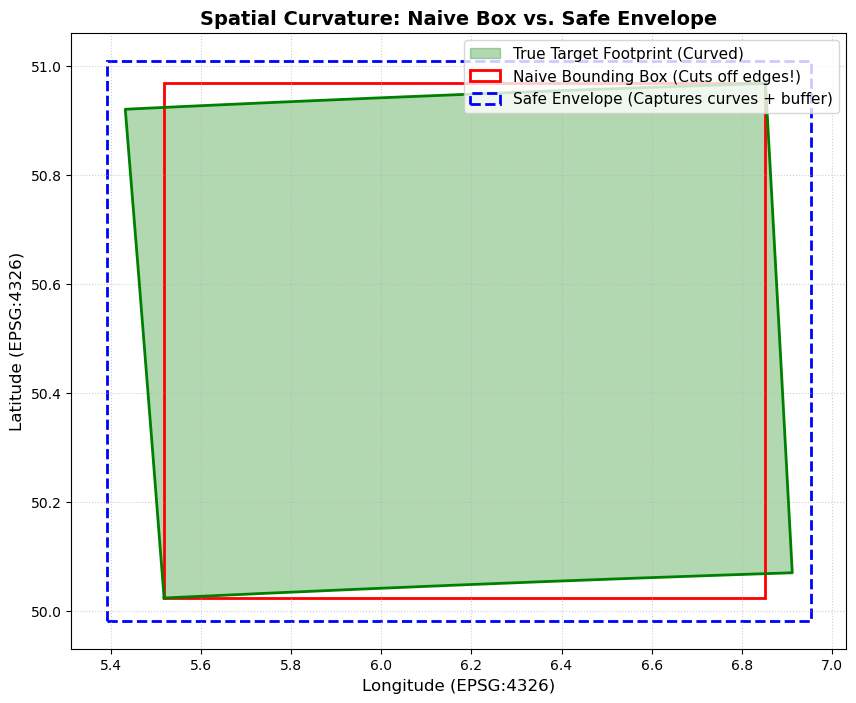

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pyproj import Transformer

# --- 1. Recreate the Densified Target Perimeter ---
minx, miny, maxx, maxy = study_area_bounds
num_points = 100 

# Create the 4 edges with 100 points each
bx = np.linspace(minx, maxx, num_points); by = np.full(num_points, miny)
rx = np.full(num_points, maxx); ry = np.linspace(miny, maxy, num_points)
tx = np.linspace(maxx, minx, num_points); ty = np.full(num_points, maxy)
lx = np.full(num_points, minx); ly = np.linspace(maxy, miny, num_points)

perimeter_x = np.concatenate([bx, rx, tx, lx])
perimeter_y = np.concatenate([by, ry, ty, ly])

# Transform the dense perimeter to WGS84
transformer = Transformer.from_crs("EPSG:3035", "EPSG:4326", always_xy=True)
true_src_x, true_src_y = transformer.transform(perimeter_x, perimeter_y)


# --- 2. Plotting the Geometries ---
fig, ax = plt.subplots(figsize=(10, 8))

# A. Plot the True Target Footprint (The curved shape)
ax.fill(true_src_x, true_src_y, alpha=0.3, color='green', label='True Target Footprint (Curved)')
ax.plot(true_src_x, true_src_y, color='green', linewidth=2)

# B. Plot the Naive Bounding Box (Red, Solid)
naive_rect = patches.Rectangle(
    (naive_minx, naive_miny), 
    naive_maxx - naive_minx, naive_maxy - naive_miny,
    linewidth=2, edgecolor='red', facecolor='none', label='Naive Bounding Box (Cuts off edges!)'
)
ax.add_patch(naive_rect)

# C. Plot the Safe Envelope (Blue, Dashed)
safe_rect = patches.Rectangle(
    (safe_bounds[0], safe_bounds[1]), 
    safe_bounds[2] - safe_bounds[0], safe_bounds[3] - safe_bounds[1],
    linewidth=2, edgecolor='blue', linestyle='--', facecolor='none', label='Safe Envelope (Captures curves + buffer)'
)
ax.add_patch(safe_rect)

# Formatting the plot
ax.set_aspect('auto')
plt.title("Spatial Curvature: Naive Box vs. Safe Envelope", fontsize=14, fontweight='bold')
plt.xlabel("Longitude (EPSG:4326)", fontsize=12)
plt.ylabel("Latitude (EPSG:4326)", fontsize=12)
plt.legend(loc='upper right', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()

## Affine reprojection & Grid snapping

Now that we understand how to safely fetch spatial data using the densified envelope, we need to mathematically align it to our master grid. The `affine_reproject` method is the core engine for this. 

Instead of doing this in-memory (which risks Out-Of-Memory crashes on large datasets), this method safely routes `xarray` objects to a temporary disk stream and invokes highly optimized **GDAL C++** bindings. 

Crucially, it guarantees perfect **Grid Snapping**. It calculates the transformed boundaries and mathematically forces the output to expand outward until its edges land precisely on the integer-aligned pixel boundaries of the target master grid. 

To demonstrate *why* our safe envelope from the previous step is so important, we will:
1. Generate dummy WGS84 data for both the Naive Box and the Safe Envelope.
2. Run `affine_reproject` on both to snap them to our metric European `EEA_1km` grid.
3. Compare the outputs to see the data loss caused by the naive approach.

### Generating dummy data

In [14]:
import xarray as xr
import numpy as np

def generate_dummy_raster(bounds, resolution, crs="EPSG:4326"):
    """Creates a synthetic continuous gradient raster for testing."""
    minx, miny, maxx, maxy = bounds
    x_coords = np.arange(minx, maxx, resolution)
    y_coords = np.arange(maxy, miny, -resolution)
    X, Y = np.meshgrid(x_coords, y_coords)
    
    # Create a simple geographic gradient pattern
    data = np.sin(X * 5) + np.cos(Y * 5)
    
    da = xr.DataArray(data.astype(np.float32), coords=[("y", y_coords), ("x", x_coords)])
    da = da.rio.write_crs(crs)
    da = da.rio.write_nodata(np.nan)
    return da

# Fetch the native resolution of our WGS84 source
wgs_res = engine.GRID_REGISTRY["Global_WGS84_30sec"]["resolution"]

# Generate our two test datasets based on the bounds calculated earlier
naive_da = generate_dummy_raster((naive_minx, naive_miny, naive_maxx, naive_maxy), wgs_res)
safe_da = generate_dummy_raster(safe_bounds, wgs_res)

print(f"Naive DataArray shape: {naive_da.shape}")
print(f"Safe DataArray shape:  {safe_da.shape}")

Naive DataArray shape: (114, 161)
Safe DataArray shape:  (124, 188)


### Executing the Reprojection

In [15]:
import os

# Create a dummy output directory
os.makedirs("test_engine_outputs", exist_ok=True)

# 1. Warp the Naive dataset
naive_warped = engine.affine_reproject(
    input_data=naive_da,
    output_filepath="test_engine_outputs/naive_warped.tif",
    grid_name=target_grid,
    resample_keyword="bilinear"
)

# 2. Warp the Safe dataset
safe_warped = engine.affine_reproject(
    input_data=safe_da,
    output_filepath="test_engine_outputs/safe_warped.tif",
    grid_name=target_grid,
    resample_keyword="bilinear"
)

print("\nReprojection complete. Data is snapped to EPSG:3035.")

Preparing out-of-core reprojection to EEA_1km...
Utilizing 'bilinear' resampling for reprojection.
Lazy xarray object detected. Preparing for disk stream...
Sanitizing spatial geometry...
Warping to test_engine_outputs/naive_warped.tif (Resampling: bilinear)...
Reprojection complete.
Preparing out-of-core reprojection to EEA_1km...
Utilizing 'bilinear' resampling for reprojection.
Lazy xarray object detected. Preparing for disk stream...
Sanitizing spatial geometry...
Warping to test_engine_outputs/safe_warped.tif (Resampling: bilinear)...
Reprojection complete.

Reprojection complete. Data is snapped to EPSG:3035.


### Visualizing the Pipeline & The NoData Trap

To understand the explicit warping that happens under the hood—and to avoid a classic remote sensing trap—we must look at the data before and after the GDAL C++ reprojection.

When taking a dataset from a geographic globe (WGS84) and flattening it into a localized metric projection (EPSG:3035), the data is physically rotated, stretched, and resampled. 

1. **Native Source (EPSG:4326):** On a geographic map, our metric study area is actually curved. The naive red bounding box completely misses the green "bulges" of our true target area.
2. **Naive Warped (EPSG:3035):** Because it missed those bulges during the fetch, the resulting reprojected raster is starved of data at its edges. 
3. **The NoData Trap:** GDAL does not automatically write `NaN` to these empty edges; it writes a specific mathematical NoData value (like `-9999.0`). If you don't explicitly mask this, standard math operations will treat the empty space as valid data!*
4. **Safe Envelope Warped (EPSG:3035):** By padding the fetch area, the engine guarantees enough surrounding pixels to calculate a perfect, wall-to-wall gradient in the final metric space.

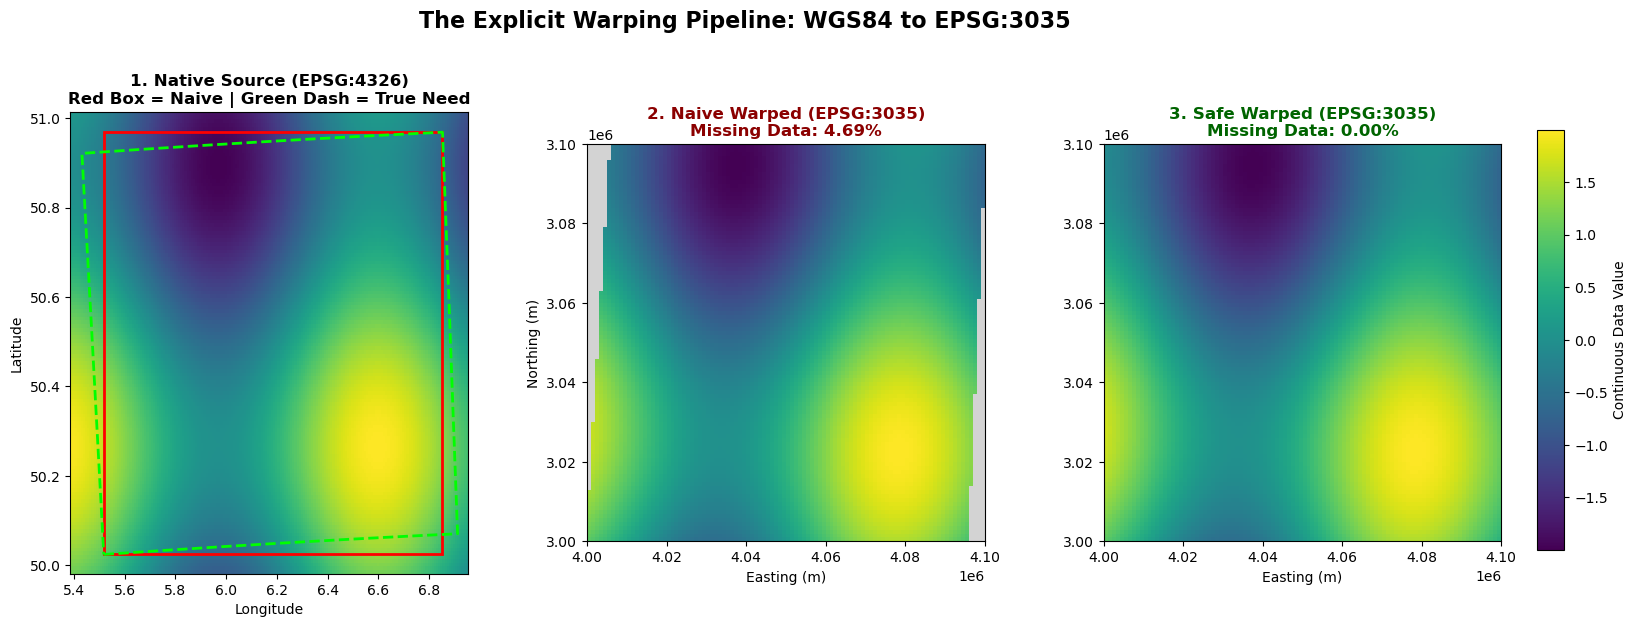

In [16]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# We want to look strictly inside our requested 100km x 100km study area
target_minx, target_miny, target_maxx, target_maxy = study_area_bounds

# Slice the warped data arrays to our exact study area bounds
naive_study_area = naive_warped.sel(
    x=slice(target_minx, target_maxx), 
    y=slice(target_maxy, target_miny) # y is usually inverted in rasters
)
safe_study_area = safe_warped.sel(
    x=slice(target_minx, target_maxx), 
    y=slice(target_maxy, target_miny)
)

# --- 1. Fix the NoData calculation ---
nodata_val = naive_study_area.rio.nodata

# Explicitly mask out the NoData values so they don't skew our statistics or plots
if nodata_val is not None:
    naive_missing = np.logical_or(np.isnan(naive_study_area), naive_study_area == nodata_val)
    safe_missing = np.logical_or(np.isnan(safe_study_area), safe_study_area == nodata_val)
else:
    naive_missing = np.isnan(naive_study_area)
    safe_missing = np.isnan(safe_study_area)

# Calculate the true percentage of data loss
naive_nan_pct = (naive_missing.sum().values / naive_study_area.size) * 100
safe_nan_pct = (safe_missing.sum().values / safe_study_area.size) * 100

# Apply the mask for plotting (makes NoData transparent)
naive_plot_da = naive_study_area.where(~naive_missing)
safe_plot_da = safe_study_area.where(~safe_missing)


# --- 2. Set up the 3-Panel Plot ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
plt.suptitle("The Explicit Warping Pipeline: WGS84 to EPSG:3035", fontsize=16, fontweight='bold', y=1.05)

# Lock the color scale so the stretching/warping effect is obvious across all plots
vmin = float(safe_da.min())
vmax = float(safe_da.max())

# --- PANEL 1: Original Data in WGS84 ---
safe_da.plot(ax=axes[0], add_colorbar=False, cmap='viridis', vmin=vmin, vmax=vmax)

# Overlay the Naive Box (Red)
naive_rect = patches.Rectangle(
    (naive_minx, naive_miny), naive_maxx - naive_minx, naive_maxy - naive_miny,
    linewidth=2, edgecolor='red', facecolor='none', linestyle='-'
)
axes[0].add_patch(naive_rect)

# Overlay the True Curved Footprint (Green)
axes[0].plot(true_src_x, true_src_y, color='lime', linewidth=2, linestyle='--')

axes[0].set_title("1. Native Source (EPSG:4326)\nRed Box = Naive | Green Dash = True Need", fontweight='bold')
axes[0].set_aspect('auto')
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")


# --- PANEL 2: Naive Reprojection (EPSG:3035) ---
naive_plot_da.plot(ax=axes[1], add_colorbar=False, cmap='viridis', vmin=vmin, vmax=vmax)

axes[1].set_title(f"2. Naive Warped (EPSG:3035)\nMissing Data: {naive_nan_pct:.2f}%", fontweight='bold', color='darkred')
axes[1].set_facecolor('lightgray') # Gray background makes the missing data corners obvious
axes[1].set_aspect('equal')
axes[1].set_xlabel("Easting (m)")
axes[1].set_ylabel("Northing (m)")


# --- PANEL 3: Safe Envelope Reprojection (EPSG:3035) ---
im = safe_plot_da.plot(ax=axes[2], add_colorbar=False, cmap='viridis', vmin=vmin, vmax=vmax)

axes[2].set_title(f"3. Safe Warped (EPSG:3035)\nMissing Data: {safe_nan_pct:.2f}%", fontweight='bold', color='darkgreen')
axes[2].set_facecolor('lightgray')
axes[2].set_aspect('equal')
axes[2].set_xlabel("Easting (m)")
axes[2].set_ylabel("")


# --- Clean up formatting ---
fig.subplots_adjust(right=0.92, wspace=0.3)
cbar_ax = fig.add_axes([0.94, 0.15, 0.015, 0.7])
fig.colorbar(im, cax=cbar_ax, label="Continuous Data Value")

plt.show()

# Clean up memory/locks
naive_warped.close()
safe_warped.close()

As demonstrated, the spatial_engine abstracts away the hazardous, complex physics of geographic reprojection. By automating densified fetch envelopes and enforcing rigid grid snapping, it guarantees that downstream ecological models are built on mathematically sound, 100% complete data footprints.